In [1]:
#遗传算法实现：求解函数 f(x) = x * sin(10πx) + 2 在区间 [-1, 2] 上的最大值

In [13]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Noto Serif CJK JP']        # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False          # 用来正常显示负号

In [14]:
# ===================== 全局参数设置（所有函数共享） =====================
# 全局变量说明：
# POPULATION_SIZE: 种群大小，每一代包含的个体数量
# CHROMOSOME_LENGTH: 染色体长度，二进制编码的位数（决定了解的精度）
# CROSSOVER_RATE: 交叉概率，两个父代个体发生基因交换的概率
# MUTATION_RATE: 变异概率，单个基因位发生翻转的概率
# GENERATIONS: 最大进化代数
# X_RANGE: 自变量x的取值范围
POPULATION_SIZE = 100
CHROMOSOME_LENGTH = 20
CROSSOVER_RATE = 0.7
MUTATION_RATE = 0.001
GENERATIONS = 200
X_RANGE = [-1, 2]

In [15]:
# ===================== 核心函数实现 =====================

def decode_chromosome(chromosome):
    """
    功能：将二进制染色体解码为指定范围内的实数
    参数：
        chromosome: ndarray，二进制染色体数组，形状为(CHROMOSOME_LENGTH,)
    返回值：
        x: float，解码后的实数，范围在[X_RANGE[0], X_RANGE[1]]之间
    运作流程：
        1. 将二进制数组转换为字符串形式
        2. 将二进制字符串转换为十进制整数
        3. 将十进制整数线性映射到指定的实数范围
    重要变量：
        全局变量：CHROMOSOME_LENGTH、X_RANGE
        局部变量：decimal（转换后的十进制整数）
    依赖关系：无
    """
    # 将二进制数组转换为字符串
    binary_str = ''.join(map(str, chromosome))
    # 将二进制字符串转换为十进制整数
    decimal = int(binary_str, 2)
    # 线性映射到目标区间
    x = X_RANGE[0] + decimal * (X_RANGE[1] - X_RANGE[0]) / (2**CHROMOSOME_LENGTH - 1)
    return x

In [16]:
def fitness_function(x):
    """
    功能：计算个体的适应度值（即目标函数值）
    参数：
        x: float，解码后的实数
    返回值：
        fitness: float，个体的适应度值
    运作流程：
        1. 代入目标函数计算函数值
        2. 直接返回函数值作为适应度（我们要最大化这个值）
    重要变量：
        局部变量：无
    依赖关系：无
    """
    return x * np.sin(10 * np.pi * x) + 2

In [17]:
def initialize_population():
    """
    功能：初始化种群，随机生成POPULATION_SIZE个二进制染色体
    参数：无
    返回值：
        population: ndarray，种群矩阵，形状为(POPULATION_SIZE, CHROMOSOME_LENGTH)
    运作流程：
        1. 生成一个形状为(POPULATION_SIZE, CHROMOSOME_LENGTH)的随机整数矩阵
        2. 矩阵中的每个元素只能是0或1
    重要变量：
        全局变量：POPULATION_SIZE、CHROMOSOME_LENGTH
        局部变量：无
    依赖关系：无
    """
    return np.random.randint(0, 2, size=(POPULATION_SIZE, CHROMOSOME_LENGTH))

In [18]:
def calculate_fitness(population):
    """
    功能：计算种群中所有个体的适应度值
    参数：
        population: ndarray，种群矩阵
    返回值：
        fitness_array: ndarray，适应度数组，形状为(POPULATION_SIZE,)
    运作流程：
        1. 遍历种群中的每个个体
        2. 对每个个体调用decode_chromosome()解码为实数
        3. 调用fitness_function()计算适应度值
        4. 将所有适应度值存入数组返回
    重要变量：
        局部变量：fitness_array（存储所有个体的适应度）
    依赖关系：decode_chromosome()、fitness_function()
    """
    fitness_array = np.zeros(POPULATION_SIZE)
    for i in range(POPULATION_SIZE):
        x = decode_chromosome(population[i])
        fitness_array[i] = fitness_function(x)
    return fitness_array

In [19]:
def select(population, fitness_array):
    """
    功能：选择操作，采用轮盘赌法选择下一代的个体
    参数：
        population: ndarray，当前种群矩阵
        fitness_array: ndarray，当前种群的适应度数组
    返回值：
        selected_population: ndarray，选择后的新种群矩阵
    运作流程：
        1. 将适应度值平移，确保所有值都是非负的（避免负数概率）
        2. 计算每个个体被选中的概率（适应度越高，概率越大）
        3. 根据概率随机选择POPULATION_SIZE个个体组成新种群
    重要变量：
        全局变量：POPULATION_SIZE
        局部变量：
            adjusted_fitness: 调整后的非负适应度数组
            probabilities: 每个个体被选中的概率数组
            selected_indices: 被选中的个体索引数组
    依赖关系：无
    """
    # 调整适应度为非负值
    adjusted_fitness = fitness_array - np.min(fitness_array) + 1e-6
    # 计算选择概率
    probabilities = adjusted_fitness / np.sum(adjusted_fitness)
    # 轮盘赌选择
    selected_indices = np.random.choice(
        POPULATION_SIZE, size=POPULATION_SIZE, p=probabilities
    )
    return population[selected_indices]

In [20]:
def crossover(population):
    """
    功能：交叉操作，采用单点交叉法交换两个个体的部分基因
    参数：
        population: ndarray，选择后的种群矩阵
    返回值：
        new_population: ndarray，交叉后的新种群矩阵
    运作流程：
        1. 将种群中的个体两两配对
        2. 对每对个体，以CROSSOVER_RATE的概率进行交叉
        3. 随机选择一个交叉点，交换交叉点之后的所有基因
        4. 将交叉后的个体加入新种群
    重要变量：
        全局变量：POPULATION_SIZE、CHROMOSOME_LENGTH、CROSSOVER_RATE
        局部变量：
            new_population: 存储交叉后的新种群
            crossover_point: 随机选择的交叉点位置
    依赖关系：无
    """
    new_population = []
    # 两两配对
    for i in range(0, POPULATION_SIZE, 2):
        parent1 = population[i].copy()
        parent2 = population[i+1].copy()
        
        # 以交叉概率进行交叉
        if np.random.rand() < CROSSOVER_RATE:
            # 随机选择交叉点（不能是0或最后一位）
            crossover_point = np.random.randint(1, CHROMOSOME_LENGTH)
            # 交换交叉点之后的基因
            parent1[crossover_point:], parent2[crossover_point:] = parent2[crossover_point:], parent1[crossover_point:]
        
        new_population.append(parent1)
        new_population.append(parent2)
    
    return np.array(new_population)

In [21]:
def mutate(population):
    """
    功能：变异操作，随机翻转染色体上的某一位基因
    参数：
        population: ndarray，交叉后的种群矩阵
    返回值：
        population: ndarray，变异后的种群矩阵
    运作流程：
        1. 遍历种群中的每个个体
        2. 遍历个体的每个基因位
        3. 以MUTATION_RATE的概率翻转该基因位（0变1，1变0）
    重要变量：
        全局变量：POPULATION_SIZE、CHROMOSOME_LENGTH、MUTATION_RATE
        局部变量：无
    依赖关系：无
    """
    for i in range(POPULATION_SIZE):
        for j in range(CHROMOSOME_LENGTH):
            if np.random.rand() < MUTATION_RATE:
                population[i, j] = 1 - population[i, j]
    return population

In [22]:
# ===================== 主算法流程 =====================

def genetic_algorithm():
    """
    功能：遗传算法主函数，执行完整的进化过程
    参数：无
    返回值：
        best_fitness_history: list，每一代的最佳适应度值
        best_x_history: list，每一代的最佳x值
        final_best_x: float，最终找到的最优x值
        final_best_fitness: float，最终找到的最优函数值
    运作流程：
        1. 调用initialize_population()初始化种群
        2. 迭代GENERATIONS次：
            a. 调用calculate_fitness()计算当前种群的适应度
            b. 记录当前代的最佳个体
            c. 调用select()进行选择操作
            d. 调用crossover()进行交叉操作
            e. 调用mutate()进行变异操作
        3. 找到最终的最优解并返回
    重要变量：
        全局变量：GENERATIONS
        局部变量：
            population: 当前种群矩阵
            best_fitness_history: 记录每代最佳适应度
            best_x_history: 记录每代最佳x值
            fitness_array: 当前代的适应度数组
    依赖关系：
        initialize_population()、calculate_fitness()、select()、
        crossover()、mutate()、decode_chromosome()
    """
    # 初始化种群
    population = initialize_population()
    best_fitness_history = []
    best_x_history = []

    # 进化迭代
    for generation in range(GENERATIONS):
        # 计算适应度
        fitness_array = calculate_fitness(population)
        
        # 记录当前代的最佳个体
        best_index = np.argmax(fitness_array)
        best_fitness = fitness_array[best_index]
        best_x = decode_chromosome(population[best_index])
        best_fitness_history.append(best_fitness)
        best_x_history.append(best_x)

        # 每20代打印一次结果
        if generation % 20 == 0:
            print(f"第{generation:3d}代 | 最佳适应度：{best_fitness:.4f} | 最佳x：{best_x:.4f}")

        # 遗传操作
        population = select(population, fitness_array)
        population = crossover(population)
        population = mutate(population)

    # 找到最终的最优解
    final_fitness = calculate_fitness(population)
    final_best_index = np.argmax(final_fitness)
    final_best_fitness = final_fitness[final_best_index]
    final_best_x = decode_chromosome(population[final_best_index])

    print("\n" + "="*50)
    print(f"最终结果：")
    print(f"最优x值：{final_best_x:.6f}")
    print(f"最优函数值：{final_best_fitness:.6f}")
    print("="*50)

    return best_fitness_history, best_x_history, final_best_x, final_best_fitness

第  0代 | 最佳适应度：3.4472 | 最佳x：1.4486
第 20代 | 最佳适应度：3.8491 | 最佳x：1.8494
第 40代 | 最佳适应度：3.8502 | 最佳x：1.8509
第 60代 | 最佳适应度：3.8503 | 最佳x：1.8507
第 80代 | 最佳适应度：3.8503 | 最佳x：1.8507
第100代 | 最佳适应度：3.8503 | 最佳x：1.8506
第120代 | 最佳适应度：3.8503 | 最佳x：1.8506
第140代 | 最佳适应度：3.8503 | 最佳x：1.8506
第160代 | 最佳适应度：3.8503 | 最佳x：1.8506
第180代 | 最佳适应度：3.8503 | 最佳x：1.8506

最终结果：
最优x值：1.850597
最优函数值：3.850272


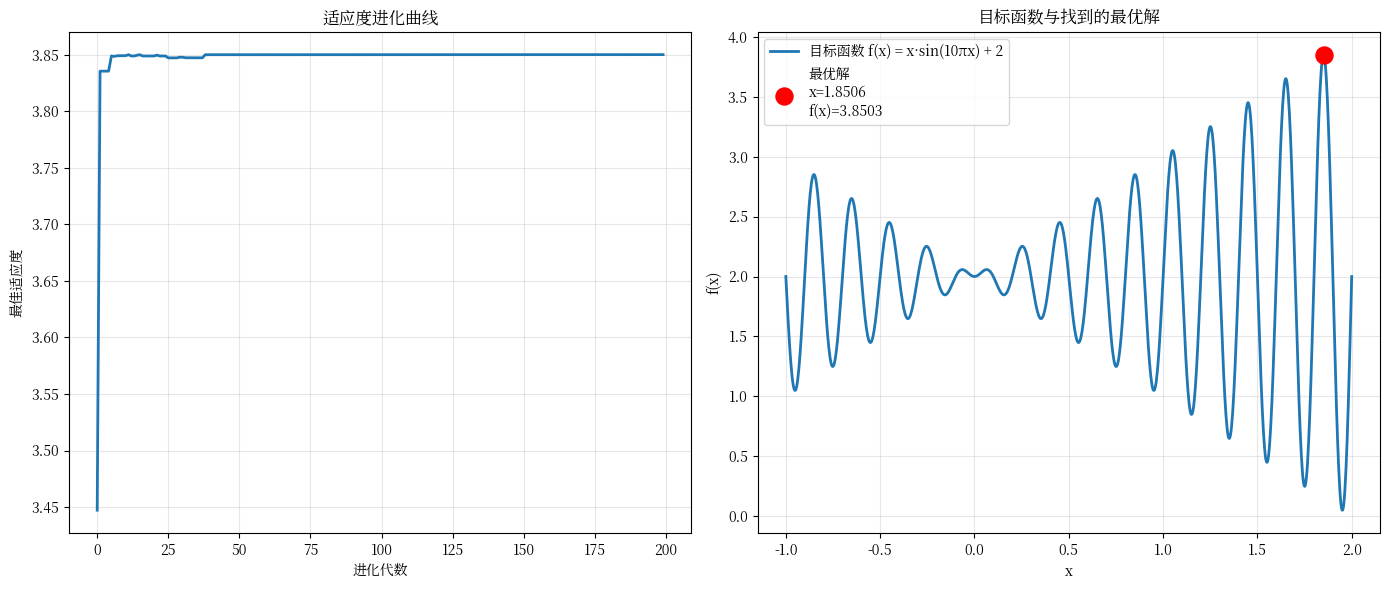

In [28]:
# ===================== 运行算法并可视化结果 =====================

if __name__ == "__main__":
    # 运行遗传算法
    best_fitness_history, best_x_history, best_x, best_fitness = genetic_algorithm()

    # 绘制结果
    plt.figure(figsize=(14, 6))

    # 左图：适应度进化曲线
    plt.subplot(1, 2, 1)
    plt.plot(best_fitness_history, linewidth=2)
    plt.xlabel('进化代数')
    plt.ylabel('最佳适应度')
    plt.title('适应度进化曲线')
    plt.grid(True, alpha=0.3)

    # 右图：目标函数与最优解
    plt.subplot(1, 2, 2)
    x = np.linspace(X_RANGE[0], X_RANGE[1], 1000)
    y = x * np.sin(10 * np.pi * x) + 2
    plt.plot(x, y, label='目标函数 f(x) = x·sin(10πx) + 2', linewidth=2)
    plt.scatter(best_x, best_fitness, c='red', s=150, zorder=5,
                label=f'最优解\nx={best_x:.4f}\nf(x)={best_fitness:.4f}')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title('目标函数与找到的最优解')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
"""
文件依赖关系说明：
1. 本代码为单文件实现，文件名：homework1_genetic_algorithm.ipynb
2. 无其他Python文件依赖
3. 依赖的第三方库：
   - numpy: 用于数值计算和矩阵操作
   - matplotlib: 用于绘制进化曲线和目标函数图
"""